# 02 · Forecasting models — probabilistic day-ahead prices

Setting: at **D-1 11:00** (before the 12:00 CET gate closure) forecast the 24 hourly prices of day D, with uncertainty.

* **Information set is enforced** by construction and by a unit test (`tests/test_features.py` perturbs the future and checks
  nothing moves): price lags ≥ 1 day, generation/load lags ≥ 48 h, weather = *forecasts*, gas lagged 2 days.
* Models: naive baselines · **LightGBM quantile regression** (P10/P50/P90) · **TiDE** (Google's Time-series Dense Encoder, PyTorch)
  · online ensemble + adaptive conformal calibration (in the backtest).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "backend").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "backend"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from gridalpha.data.lake import get_lake
from gridalpha.data.ingest import ingest

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "font.size": 10})
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#898781"
lake = get_lake()
if not lake.exists("market_hourly"):
    ingest()          # auto: public APIs, falls back to the calibrated simulator
meta = lake.read_json("data_meta")
print("data mode:", meta["mode"], "| rows:", meta["rows"], "| last price:", meta["last_price_ts"])

data mode: synthetic | rows: 32807 | last price: 2026-09-26T21:00:00+00:00


In [2]:
from gridalpha.features.builder import build_features, FEATURES, training_rows
feat = build_features(lake.read("market_hourly"))
print(len(FEATURES), "features");
feat[FEATURES].describe().T[["mean", "std", "min", "max"]].round(2).head(15)

37 features


,mean,std,min,max
hour,11.50,6.92,0.00,23.00
dow,3.00,2.00,0.00,6.00
month,6.22,3.35,1.00,12.00
is_offday,0.31,0.46,0.00,1.00
is_holiday,0.02,0.15,0.00,1.00
doy_sin,0.04,0.71,-1.00,1.00
doy_cos,-0.04,0.71,-1.00,1.00
hour_sin,-0.00,0.71,-1.00,1.00
hour_cos,-0.00,0.71,-1.00,1.00
temp_fc,10.58,8.07,-11.49,34.42


In [3]:
from gridalpha.models.baselines import NaiveD1, Profile7
from gridalpha.models.lgbm import LGBMQuantile, global_shap_importance
from gridalpha.models.metrics import forecast_metrics
days_all = sorted(training_rows(feat)["delivery_date"].unique())
cut = pd.Timestamp(days_all[-60])                       # hold out the last 60 delivery days
test_days = [pd.Timestamp(d) for d in days_all[-60:]]
res, preds = {}, {}
for M in (NaiveD1, Profile7, LGBMQuantile):
    m = M().fit(feat, cut)
    p = m.predict(feat, test_days).join(feat[["price", "delivery_date"]]).rename(columns={"price": "actual"})
    preds[m.name], res[m.name] = p, forecast_metrics(p)
    if m.name == "lgbm": lgbm = m

In [4]:
try:
    from gridalpha.models.tide import TiDEQuantile, TORCH_OK
    if TORCH_OK:
        t = TiDEQuantile(seeds=1).fit(feat, cut)
        p = t.predict(feat, test_days).join(feat[["price", "delivery_date"]]).rename(columns={"price": "actual"})
        preds["tide"], res["tide"] = p, forecast_metrics(p)
        print(t.history)
except Exception as e:
    print("TiDE skipped:", e)
pd.DataFrame(res).T[["mae", "rmse", "pinball", "coverage_80", "kendall_tau", "peak_hour_hit", "trough_hour_hit"]].round(3)

02:12:55 | INFO    | gridalpha.tide | TiDE trained on 1298 days: [{'seed': 42, 'epochs': 49, 'warm_start': False, 'val_pinball_norm': 0.1337}]


[{'seed': 42, 'epochs': 49, 'warm_start': False, 'val_pinball_norm': 0.1337}]


,mae,rmse,pinball,coverage_80,kendall_tau,peak_hour_hit,trough_hour_hit
naive_d1,21.505,29.657,7.411,0.867,0.676,0.767,0.850
profile7,22.525,31.035,8.178,0.930,0.738,0.850,0.850
lgbm,10.319,14.470,3.525,0.662,0.837,0.850,0.850
tide,11.866,16.197,3.971,0.755,0.822,0.883,0.883


Reading the table: MAE/RMSE/pinball measure accuracy; **coverage_80** should be ≈ 0.80 for a calibrated P10–P90 band (raw GBM quantiles
are usually too narrow → the backtest applies adaptive conformal scaling); **Kendall τ / peak-hour hit** measure whether the hours are
*ranked* correctly — what a battery actually monetises.

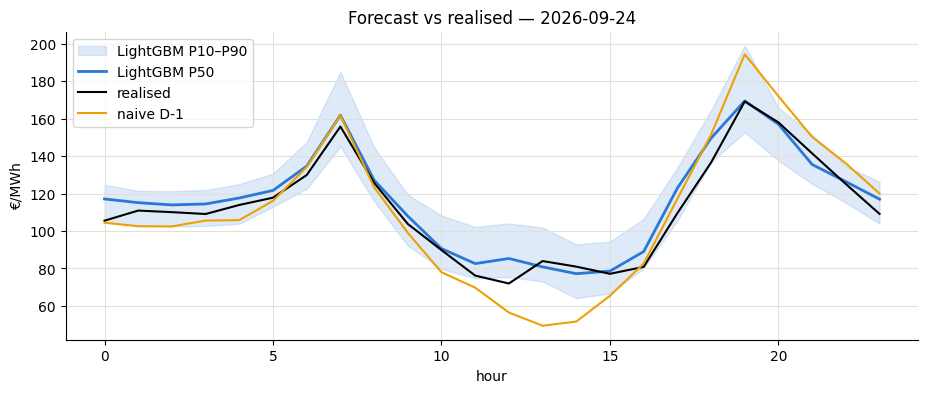

In [5]:
d = preds["lgbm"][preds["lgbm"].delivery_date == test_days[-3]].sort_index()
fig, ax = plt.subplots()
x = d.index.tz_convert("Europe/Berlin").hour
ax.fill_between(x, d.q10, d.q90, color=BLUE, alpha=.15, label="LightGBM P10–P90")
ax.plot(x, d.q50, color=BLUE, lw=2, label="LightGBM P50")
ax.plot(x, d.actual, color="black", lw=1.5, label="realised")
nd = preds["naive_d1"].loc[d.index]
ax.plot(x, nd.q50, color=YELLOW, lw=1.5, label="naive D-1")
ax.set(title=f"Forecast vs realised — {test_days[-3].date()}", xlabel="hour", ylabel="€/MWh"); ax.legend(); plt.show()

## Explainability — TreeSHAP (native in LightGBM, no extra dependency)

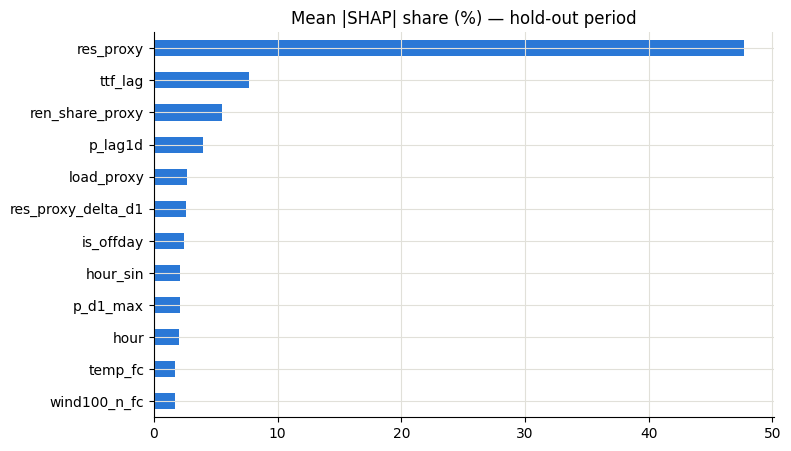

In [6]:
imp = global_shap_importance(lgbm, feat[feat.delivery_date.isin(test_days)])
imp.head(12)[::-1].plot(kind="barh", color=BLUE, figsize=(8, 5), title="Mean |SHAP| share (%) — hold-out period"); plt.show()

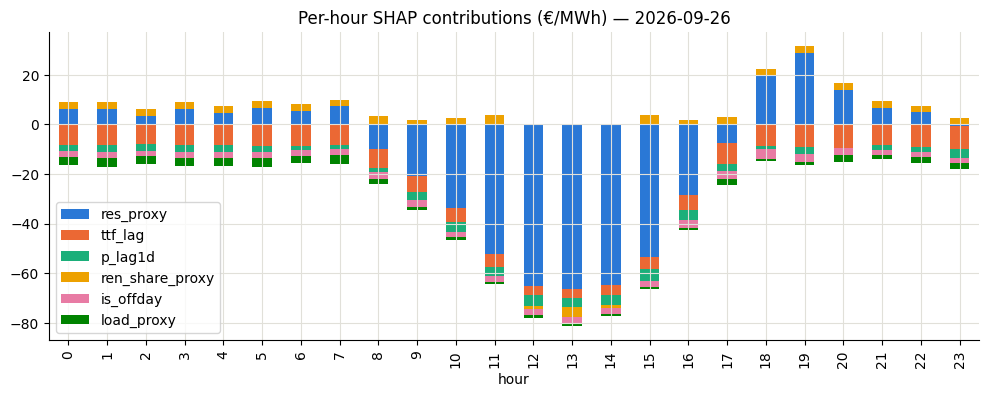

In [7]:
rows = feat[feat.delivery_date == test_days[-1]]
sv = lgbm.shap(rows).drop(columns="_base")
top = sv.abs().mean().sort_values(ascending=False).index[:6]
sv[top].set_index(rows.hour).plot(kind="bar", stacked=True, figsize=(12, 4),
    color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN], title=f"Per-hour SHAP contributions (€/MWh) — {test_days[-1].date()}")
plt.show()

## Error by hour — where is the problem hard?

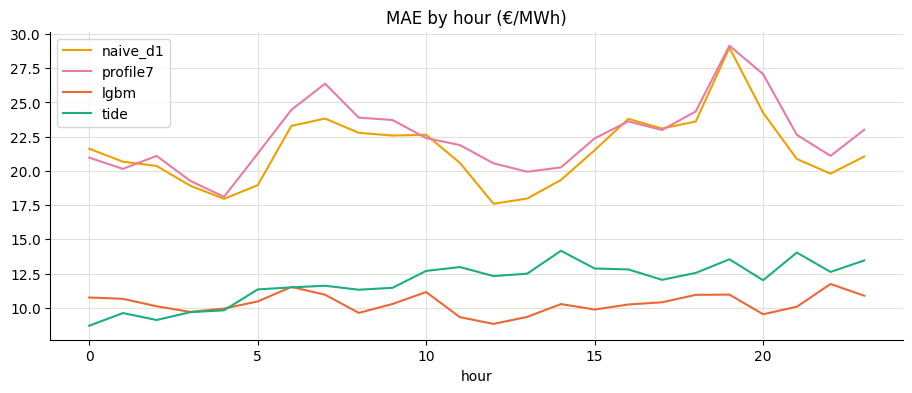

In [8]:
eh = pd.DataFrame({k: (v.actual - v.q50).abs().groupby(v.index.tz_convert("Europe/Berlin").hour).mean() for k, v in preds.items()})
eh.plot(color=[YELLOW, MAGENTA, ORANGE, AQUA][: eh.shape[1]], title="MAE by hour (€/MWh)", xlabel="hour"); plt.show()

**Takeaways**
* Gradient boosting on well-designed fundamental features (residual-load proxies, price memory) is the strongest single model —
  the merit order is piecewise, which trees capture naturally.
* TiDE brings a different inductive bias (multi-horizon, whole-day shape) → useful in the ensemble on regime changes; its weight is
  learned online from recent pinball loss rather than fixed by hand.
* Calibration matters as much as accuracy for the decision layer: scenarios are sampled from these quantiles (notebook 03).